**Section:1 ------->>>>>> Data Loading & Preprocessing**

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/Raw_data.csv")

In [3]:
df.head()

,case_id,activity,timestamp,resource
0,1,Order_Placed,03-01-2024 21:00,Customer
1,1,Order_Validated,03-01-2024 21:09,System
2,1,Payment_Processed,03-01-2024 21:17,Payment_Gateway
3,1,Inventory_Checked,03-01-2024 21:39,Warehouse_System
4,1,Warehouse_A,03-01-2024 21:46,Warehouse_Staff


In [4]:
df['timestamp']=pd.to_datetime(df['timestamp'],format='%d-%m-%Y %H:%M')

In [5]:
df.head()

,case_id,activity,timestamp,resource
0,1,Order_Placed,2024-01-03 21:00:00,Customer
1,1,Order_Validated,2024-01-03 21:09:00,System
2,1,Payment_Processed,2024-01-03 21:17:00,Payment_Gateway
3,1,Inventory_Checked,2024-01-03 21:39:00,Warehouse_System
4,1,Warehouse_A,2024-01-03 21:46:00,Warehouse_Staff


In [6]:
df.sort_values(by=['case_id','timestamp'], inplace=True)

In [7]:
df.head(10)

,case_id,activity,timestamp,resource
0,1,Order_Placed,2024-01-03 21:00:00,Customer
1,1,Order_Validated,2024-01-03 21:09:00,System
2,1,Payment_Processed,2024-01-03 21:17:00,Payment_Gateway
3,1,Inventory_Checked,2024-01-03 21:39:00,Warehouse_System
4,1,Warehouse_A,2024-01-03 21:46:00,Warehouse_Staff
5,1,Packed,2024-01-03 22:09:00,Warehouse_Staff
6,1,Order_Processed,2024-01-03 23:18:00,Warehouse_Staff
7,1,Route_A,2024-01-03 23:39:00,Transport
8,1,Out_for_Delivery,2024-01-04 00:55:00,Delivery_Agent
9,1,Delivered,2024-01-04 01:20:00,Delivery_Agent


In [8]:
case_df = df.pivot_table(
    index="case_id",
    columns="activity",
    values="timestamp",
    aggfunc="first"
).reset_index()
case_df.columns.name = None

In [9]:
case_df.head()

,case_id,Delivered,Inventory_Checked,Order_Placed,Order_Processed,Order_Validated,Out_for_Delivery,Packed,Payment_Processed,Route_A,Route_B,Route_C,Route_D,Warehouse_A,Warehouse_B,Warehouse_C
0,1,2024-01-04 01:20:00,2024-01-03 21:39:00,2024-01-03 21:00:00,2024-01-03 23:18:00,2024-01-03 21:09:00,2024-01-04 00:55:00,2024-01-03 22:09:00,2024-01-03 21:17:00,2024-01-03 23:39:00,NaT,NaT,NaT,2024-01-03 21:46:00,NaT,NaT
1,2,2024-01-13 22:18:00,2024-01-13 18:22:00,2024-01-13 17:49:00,2024-01-13 21:22:00,2024-01-13 17:54:00,2024-01-13 21:59:00,2024-01-13 20:02:00,2024-01-13 18:04:00,NaT,2024-01-13 21:46:00,NaT,NaT,NaT,2024-01-13 19:03:00,NaT
2,3,2024-01-13 16:33:00,2024-01-13 13:59:00,2024-01-13 12:58:00,2024-01-13 15:50:00,2024-01-13 13:20:00,2024-01-13 16:16:00,2024-01-13 14:39:00,2024-01-13 13:34:00,NaT,NaT,2024-01-13 16:04:00,NaT,2024-01-13 14:23:00,NaT,NaT
3,4,2024-01-07 20:23:00,2024-01-07 16:41:00,2024-01-07 15:58:00,2024-01-07 18:29:00,2024-01-07 16:14:00,2024-01-07 19:58:00,2024-01-07 18:19:00,2024-01-07 16:30:00,NaT,NaT,2024-01-07 19:45:00,NaT,NaT,2024-01-07 16:54:00,NaT
4,5,2024-01-14 04:46:00,2024-01-14 00:49:00,2024-01-14 00:16:00,2024-01-14 03:51:00,2024-01-14 00:28:00,2024-01-14 04:33:00,2024-01-14 02:15:00,2024-01-14 00:34:00,2024-01-14 04:08:00,NaT,NaT,NaT,2024-01-14 01:06:00,NaT,NaT


In [10]:
warehouse_map = df[df["activity"].str.startswith("Warehouse_")][["case_id", "activity"]].rename(columns={"activity": "warehouse"})
route_map     = df[df["activity"].str.startswith("Route_")][["case_id", "activity"]].rename(columns={"activity": "route"})
case_df = case_df.merge(warehouse_map, on="case_id", how="left")
case_df = case_df.merge(route_map,     on="case_id", how="left")

In [11]:
case_df["warehouse_ts"] = case_df["Warehouse_A"].fillna(
                          case_df["Warehouse_B"].fillna(
                          case_df["Warehouse_C"]))

case_df["route_ts"] = case_df["Route_A"].fillna(
                      case_df["Route_B"].fillna(
                      case_df["Route_C"].fillna(
                      case_df["Route_D"])))

In [12]:
case_df.columns

Index(['case_id', 'Delivered', 'Inventory_Checked', 'Order_Placed',
       'Order_Processed', 'Order_Validated', 'Out_for_Delivery', 'Packed',
       'Payment_Processed', 'Route_A', 'Route_B', 'Route_C', 'Route_D',
       'Warehouse_A', 'Warehouse_B', 'Warehouse_C', 'warehouse', 'route',
       'warehouse_ts', 'route_ts'],
      dtype='object')

In [13]:
df.head(10)

,case_id,activity,timestamp,resource
0,1,Order_Placed,2024-01-03 21:00:00,Customer
1,1,Order_Validated,2024-01-03 21:09:00,System
2,1,Payment_Processed,2024-01-03 21:17:00,Payment_Gateway
3,1,Inventory_Checked,2024-01-03 21:39:00,Warehouse_System
4,1,Warehouse_A,2024-01-03 21:46:00,Warehouse_Staff
5,1,Packed,2024-01-03 22:09:00,Warehouse_Staff
6,1,Order_Processed,2024-01-03 23:18:00,Warehouse_Staff
7,1,Route_A,2024-01-03 23:39:00,Transport
8,1,Out_for_Delivery,2024-01-04 00:55:00,Delivery_Agent
9,1,Delivered,2024-01-04 01:20:00,Delivery_Agent


**SECTION**: **2** ------>>> **Feature Engineering**

In [14]:
wait_cols = [
    'wait_Order_Validated',
    'wait_Payment_Processed',
    'wait_Inventory_Checked',
    'wait_warehouse_assign_min',
    'wait_Packed',
    'wait_Order_Processed',
    'wait_Route_ts',
    'wait_Out_for_Delivery',
    'wait_Delivered'
]

# Stage with maximum wait = bottleneck stage


In [15]:
case_df["wait_Order_Validated"]=(case_df["Order_Validated"]-case_df["Order_Placed"]).dt.total_seconds() / 60
case_df["wait_Payment_Processed"]=(case_df["Payment_Processed"]-case_df["Order_Validated"]).dt.total_seconds() / 60
case_df["wait_Inventory_Checked"]=(case_df["Inventory_Checked"]-case_df["Payment_Processed"]).dt.total_seconds() / 60
case_df["wait_warehouse_assign_min"]=(case_df["warehouse_ts"]-case_df["Inventory_Checked"]).dt.total_seconds() / 60
case_df["wait_Packed"]=(case_df["Packed"]-case_df["warehouse_ts"]).dt.total_seconds() / 60
case_df["wait_Order_Processed"]=(case_df["Order_Processed"]-case_df["Packed"]).dt.total_seconds() / 60
case_df["wait_Route_ts"]=(case_df["route_ts"]-case_df["Order_Processed"]).dt.total_seconds() / 60
case_df["wait_Out_for_Delivery"]=(case_df["Out_for_Delivery"]-case_df["route_ts"]).dt.total_seconds() / 60
case_df["wait_Delivered"]=(case_df["Delivered"]-case_df["Out_for_Delivery"]).dt.total_seconds() / 60



In [16]:
case_df["early_delay_Order_Validated"]=case_df["wait_Order_Validated"]-case_df["wait_Order_Validated"].mean()
case_df["early_delay_Payment_Processed"]=case_df["wait_Payment_Processed"]-case_df["wait_Payment_Processed"].mean()
case_df["early_delay_Inventory_Checked"]=case_df["wait_Inventory_Checked"]-case_df["wait_Inventory_Checked"].mean()
case_df["early_delay_warehouse_assign_min"]=case_df["wait_warehouse_assign_min"]-case_df["wait_warehouse_assign_min"].mean()

case_df["early_delay_total"] = (case_df["early_delay_Order_Validated"]+
                                case_df["early_delay_Payment_Processed"]+
                                case_df["early_delay_Inventory_Checked"]+
                                case_df["early_delay_warehouse_assign_min"])

In [17]:
early_delay_cols = [
    'early_delay_Order_Validated',
    'early_delay_Payment_Processed',
    'early_delay_Inventory_Checked',
    'early_delay_warehouse_assign_min'
]
case_df["early_delay_max"] = case_df[early_delay_cols].max(axis=1)

In [18]:
case_df['wait_std_early'] = case_df[
    ['wait_Order_Validated','wait_Payment_Processed',
     'wait_Inventory_Checked','wait_warehouse_assign_min']
].std(axis=1)

In [19]:
case_df['dominance_ratio'] = case_df[
    ['wait_Order_Validated','wait_Payment_Processed',
     'wait_Inventory_Checked','wait_warehouse_assign_min']
].max(axis=1) / case_df['early_delay_total']

In [20]:
case_df["hour_of_order"]=case_df["Order_Placed"].dt.hour
case_df["day_of_order"]=case_df["Order_Placed"].dt.day
case_df["month_of_order"]=case_df["Order_Placed"].dt.month
case_df["day_of_week"] = case_df["Order_Placed"].dt.dayofweek
case_df['is_weekend'] = case_df['Order_Placed'].dt.dayofweek.isin([5, 6]).astype(int)
# 5 = Saturday, 6 = Sunday

In [21]:
case_df['is_peak_hour'] = case_df['hour_of_order'].isin([8, 19, 23, 21, 22]).astype(int)

In [22]:
case_df['is_night_order'] = case_df['hour_of_order'].isin([0,1,2,3,4]).astype(int)
case_df['quarter']        = case_df['Order_Placed'].dt.quarter

In [23]:
case_df["total_lead_time_min"] = (case_df["Delivered"] - case_df["Order_Placed"]).dt.total_seconds() / 60

In [24]:
route_warehouse_cols = ['Route_A', 'Route_B', 'Route_C', 'Route_D', 'Warehouse_A', 'Warehouse_B', 'Warehouse_C']
for col in route_warehouse_cols:
    case_df[col] = case_df[col].notna().astype(int)

print("Converted 'Route' and 'Warehouse' columns to binary indicators.")
case_df.head()

Converted 'Route' and 'Warehouse' columns to binary indicators.


,case_id,Delivered,Inventory_Checked,Order_Placed,Order_Processed,Order_Validated,Out_for_Delivery,Packed,Payment_Processed,Route_A,...,dominance_ratio,hour_of_order,day_of_order,month_of_order,day_of_week,is_weekend,is_peak_hour,is_night_order,quarter,total_lead_time_min
0,1,2024-01-04 01:20:00,2024-01-03 21:39:00,2024-01-03 21:00:00,2024-01-03 23:18:00,2024-01-03 21:09:00,2024-01-04 00:55:00,2024-01-03 22:09:00,2024-01-03 21:17:00,1,...,-0.642467,21,3,1,2,0,1,0,1,260.0
1,2,2024-01-13 22:18:00,2024-01-13 18:22:00,2024-01-13 17:49:00,2024-01-13 21:22:00,2024-01-13 17:54:00,2024-01-13 21:59:00,2024-01-13 20:02:00,2024-01-13 18:04:00,0,...,-6.567355,17,13,1,5,1,0,0,1,269.0
2,3,2024-01-13 16:33:00,2024-01-13 13:59:00,2024-01-13 12:58:00,2024-01-13 15:50:00,2024-01-13 13:20:00,2024-01-13 16:16:00,2024-01-13 14:39:00,2024-01-13 13:34:00,0,...,5.255413,12,13,1,5,1,0,0,1,215.0
3,4,2024-01-07 20:23:00,2024-01-07 16:41:00,2024-01-07 15:58:00,2024-01-07 18:29:00,2024-01-07 16:14:00,2024-01-07 19:58:00,2024-01-07 18:19:00,2024-01-07 16:30:00,0,...,-0.659984,15,7,1,6,1,0,0,1,265.0
4,5,2024-01-14 04:46:00,2024-01-14 00:49:00,2024-01-14 00:16:00,2024-01-14 03:51:00,2024-01-14 00:28:00,2024-01-14 04:33:00,2024-01-14 02:15:00,2024-01-14 00:34:00,1,...,-0.562114,0,14,1,6,1,0,1,1,270.0


In [25]:
df.columns

Index(['case_id', 'activity', 'timestamp', 'resource'], dtype='object')

In [26]:
case_df.columns

Index(['case_id', 'Delivered', 'Inventory_Checked', 'Order_Placed',
       'Order_Processed', 'Order_Validated', 'Out_for_Delivery', 'Packed',
       'Payment_Processed', 'Route_A', 'Route_B', 'Route_C', 'Route_D',
       'Warehouse_A', 'Warehouse_B', 'Warehouse_C', 'warehouse', 'route',
       'warehouse_ts', 'route_ts', 'wait_Order_Validated',
       'wait_Payment_Processed', 'wait_Inventory_Checked',
       'wait_warehouse_assign_min', 'wait_Packed', 'wait_Order_Processed',
       'wait_Route_ts', 'wait_Out_for_Delivery', 'wait_Delivered',
       'early_delay_Order_Validated', 'early_delay_Payment_Processed',
       'early_delay_Inventory_Checked', 'early_delay_warehouse_assign_min',
       'early_delay_total', 'early_delay_max', 'wait_std_early',
       'dominance_ratio', 'hour_of_order', 'day_of_order', 'month_of_order',
       'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_order',
       'quarter', 'total_lead_time_min'],
      dtype='object')

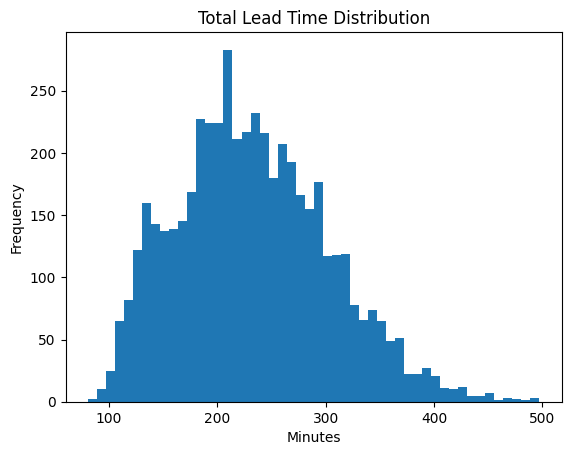

In [27]:
import matplotlib.pyplot as plt

plt.hist(case_df['total_lead_time_min'], bins=50)
plt.title("Total Lead Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

In [28]:
print(case_df['total_lead_time_min'].skew())

0.4215604934914241


In [29]:
threshold = case_df['total_lead_time_min'].mean() + case_df['total_lead_time_min'].std()

case_df['is_bottleneck'] = (case_df['total_lead_time_min'] > threshold).astype(int)

print(case_df['is_bottleneck'].value_counts(normalize=True))

is_bottleneck
0    0.837
1    0.163
Name: proportion, dtype: float64


In [30]:
threshold = case_df['total_lead_time_min'].quantile(0.80)
case_df['is_bottleneck'] = (case_df['total_lead_time_min'] > threshold).astype(int)

#performing best 80quantile  recall 68 accu 77


In [31]:
print(case_df['is_bottleneck'].value_counts(normalize=True))

is_bottleneck
0    0.8032
1    0.1968
Name: proportion, dtype: float64


In [32]:
threshold

np.float64(292.0)

In [33]:
# How has this warehouse performed historically?
warehouse_bottleneck_rate = case_df.groupby('warehouse')['is_bottleneck'].mean()
case_df['warehouse_bottleneck_rate'] = case_df['warehouse'].map(warehouse_bottleneck_rate)


# Average lead time by warehouse
warehouse_avg_lead = case_df.groupby('warehouse')['total_lead_time_min'].mean()
case_df['warehouse_avg_lead'] = case_df['warehouse'].map(warehouse_avg_lead)

In [34]:
bottleneck_count = case_df[case_df['is_bottleneck'] == 1].shape[0]
print(f"Number of rows with bottleneck present: {bottleneck_count}")

Number of rows with bottleneck present: 984


In [35]:
case_df.columns

Index(['case_id', 'Delivered', 'Inventory_Checked', 'Order_Placed',
       'Order_Processed', 'Order_Validated', 'Out_for_Delivery', 'Packed',
       'Payment_Processed', 'Route_A', 'Route_B', 'Route_C', 'Route_D',
       'Warehouse_A', 'Warehouse_B', 'Warehouse_C', 'warehouse', 'route',
       'warehouse_ts', 'route_ts', 'wait_Order_Validated',
       'wait_Payment_Processed', 'wait_Inventory_Checked',
       'wait_warehouse_assign_min', 'wait_Packed', 'wait_Order_Processed',
       'wait_Route_ts', 'wait_Out_for_Delivery', 'wait_Delivered',
       'early_delay_Order_Validated', 'early_delay_Payment_Processed',
       'early_delay_Inventory_Checked', 'early_delay_warehouse_assign_min',
       'early_delay_total', 'early_delay_max', 'wait_std_early',
       'dominance_ratio', 'hour_of_order', 'day_of_order', 'month_of_order',
       'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_order',
       'quarter', 'total_lead_time_min', 'is_bottleneck',
       'warehouse_bottleneck_rate'

In [36]:
case_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   case_id                           5000 non-null   int64         
 1   Delivered                         5000 non-null   datetime64[ns]
 2   Inventory_Checked                 5000 non-null   datetime64[ns]
 3   Order_Placed                      5000 non-null   datetime64[ns]
 4   Order_Processed                   5000 non-null   datetime64[ns]
 5   Order_Validated                   5000 non-null   datetime64[ns]
 6   Out_for_Delivery                  5000 non-null   datetime64[ns]
 7   Packed                            5000 non-null   datetime64[ns]
 8   Payment_Processed                 5000 non-null   datetime64[ns]
 9   Route_A                           5000 non-null   int64         
 10  Route_B                           5000 non-null 

In [37]:
case_df.columns

Index(['case_id', 'Delivered', 'Inventory_Checked', 'Order_Placed',
       'Order_Processed', 'Order_Validated', 'Out_for_Delivery', 'Packed',
       'Payment_Processed', 'Route_A', 'Route_B', 'Route_C', 'Route_D',
       'Warehouse_A', 'Warehouse_B', 'Warehouse_C', 'warehouse', 'route',
       'warehouse_ts', 'route_ts', 'wait_Order_Validated',
       'wait_Payment_Processed', 'wait_Inventory_Checked',
       'wait_warehouse_assign_min', 'wait_Packed', 'wait_Order_Processed',
       'wait_Route_ts', 'wait_Out_for_Delivery', 'wait_Delivered',
       'early_delay_Order_Validated', 'early_delay_Payment_Processed',
       'early_delay_Inventory_Checked', 'early_delay_warehouse_assign_min',
       'early_delay_total', 'early_delay_max', 'wait_std_early',
       'dominance_ratio', 'hour_of_order', 'day_of_order', 'month_of_order',
       'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_order',
       'quarter', 'total_lead_time_min', 'is_bottleneck',
       'warehouse_bottleneck_rate'

### **SECTION:3 ------->>>>> Model Training: Bottleneck**


In [38]:
case_df_features=case_df[[

'Warehouse_A', 'Warehouse_B', 'Warehouse_C',

'is_peak_hour',"is_weekend","is_night_order"  ,"quarter"  ,
'hour_of_order', 'day_of_order', 'month_of_order',

"early_delay_Order_Validated","early_delay_Payment_Processed",
"early_delay_Inventory_Checked","early_delay_warehouse_assign_min",
"early_delay_total",

"warehouse_avg_lead",
'wait_std_early',
"dominance_ratio",
#>>>> diminance needs fixing outlier
                          # "warehouse_bottleneck_rate",--->>> creating leakage address in resume search for why
 "early_delay_max",
 'wait_Order_Validated',
 'wait_Payment_Processed',
 'wait_Inventory_Checked',
 'wait_warehouse_assign_min',


  'is_bottleneck',


                          ]]

In [39]:
case_df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Warehouse_A                       5000 non-null   int64  
 1   Warehouse_B                       5000 non-null   int64  
 2   Warehouse_C                       5000 non-null   int64  
 3   is_peak_hour                      5000 non-null   int64  
 4   is_weekend                        5000 non-null   int64  
 5   is_night_order                    5000 non-null   int64  
 6   quarter                           5000 non-null   int32  
 7   hour_of_order                     5000 non-null   int32  
 8   day_of_order                      5000 non-null   int32  
 9   month_of_order                    5000 non-null   int32  
 10  early_delay_Order_Validated       5000 non-null   float64
 11  early_delay_Payment_Processed     5000 non-null   float64
 12  early_

In [40]:
X = case_df_features.drop("is_bottleneck", axis=1)
y = case_df_features["is_bottleneck"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000,class_weight="balanced")


model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [50]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=10, n_estimators=500, random_state=42)

In [44]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=5,
    eval_metric="aucpr",
    # helps with imbalanced classes
    gamma=0.1,
    random_state=42,

)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))

[[585 218]
 [ 64 133]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.81       803
           1       0.38      0.68      0.49       197

    accuracy                           0.72      1000
   macro avg       0.64      0.70      0.65      1000
weighted avg       0.80      0.72      0.74      1000

Accuracy: 0.718

ROC-AUC: 0.70182248041924


In [47]:
case_df_features.corr()["is_bottleneck"].sort_values(ascending=False)

,is_bottleneck
is_bottleneck,1.000000
early_delay_total,0.311181
early_delay_warehouse_assign_min,0.300037
wait_warehouse_assign_min,0.300037
early_delay_max,0.293194
wait_std_early,0.288012
warehouse_avg_lead,0.154253
Warehouse_C,0.144159
wait_Order_Validated,0.060776
early_delay_Order_Validated,0.060776


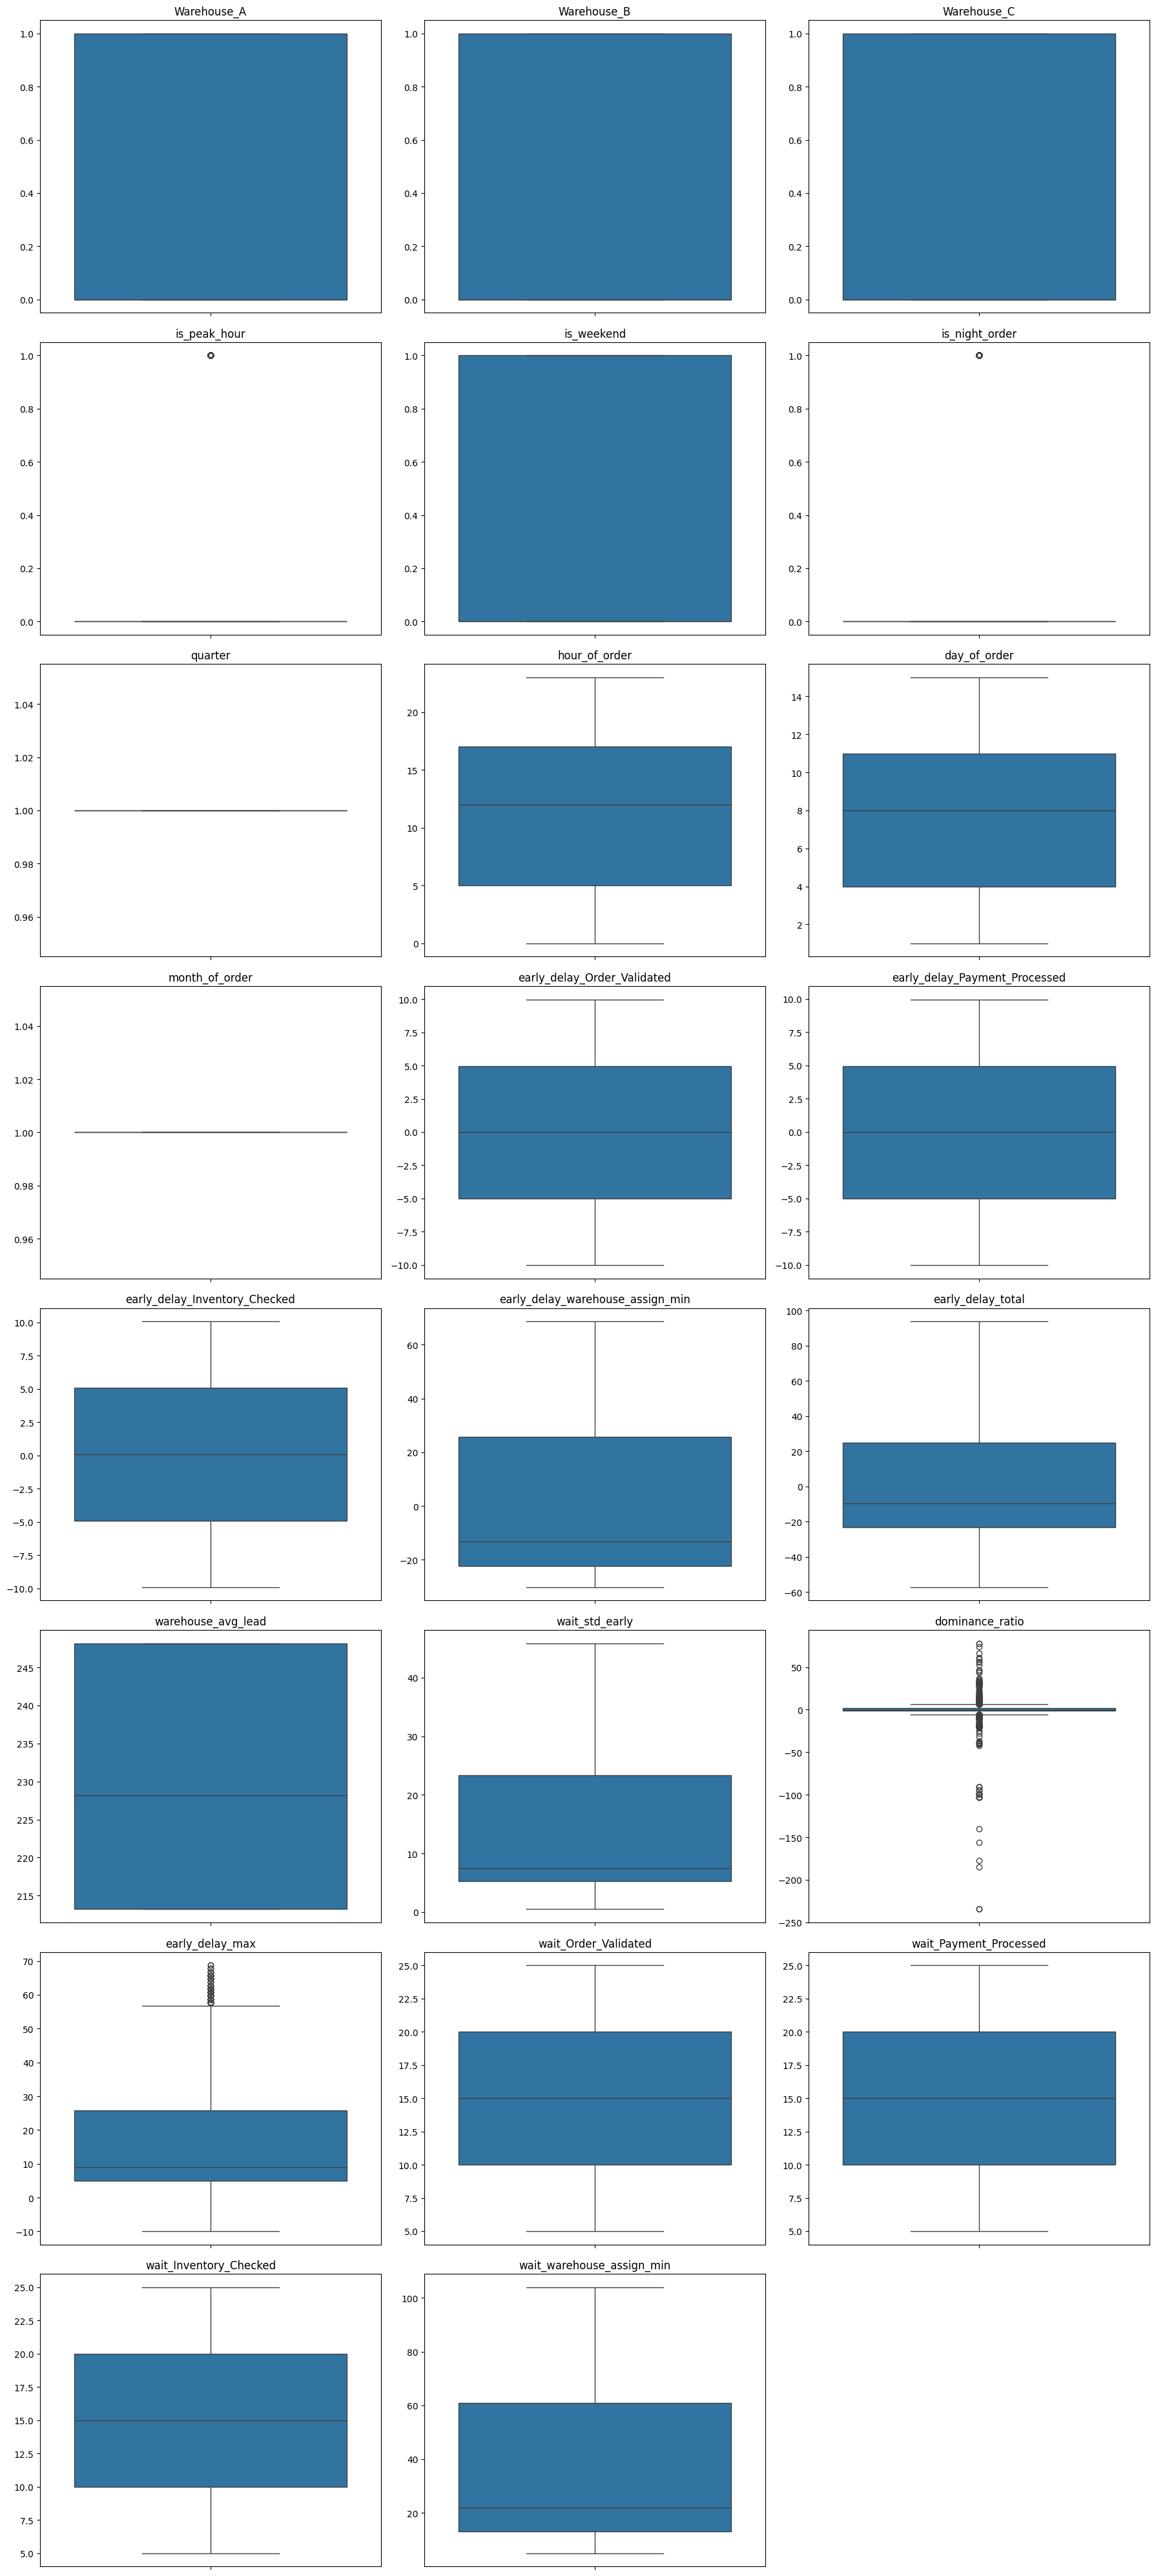

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numerical columns from case_df_features, excluding 'is_bottleneck'
numerical_cols = case_df_features.select_dtypes(include=np.number).columns.tolist()
if 'is_bottleneck' in numerical_cols:
    numerical_cols.remove('is_bottleneck')

# Determine subplot grid size dynamically
num_cols = len(numerical_cols)
num_rows = int(np.ceil(num_cols / 3))  # Aim for 3 columns per row
num_cols_per_row = 3

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(18, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(y=case_df_features[col], ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

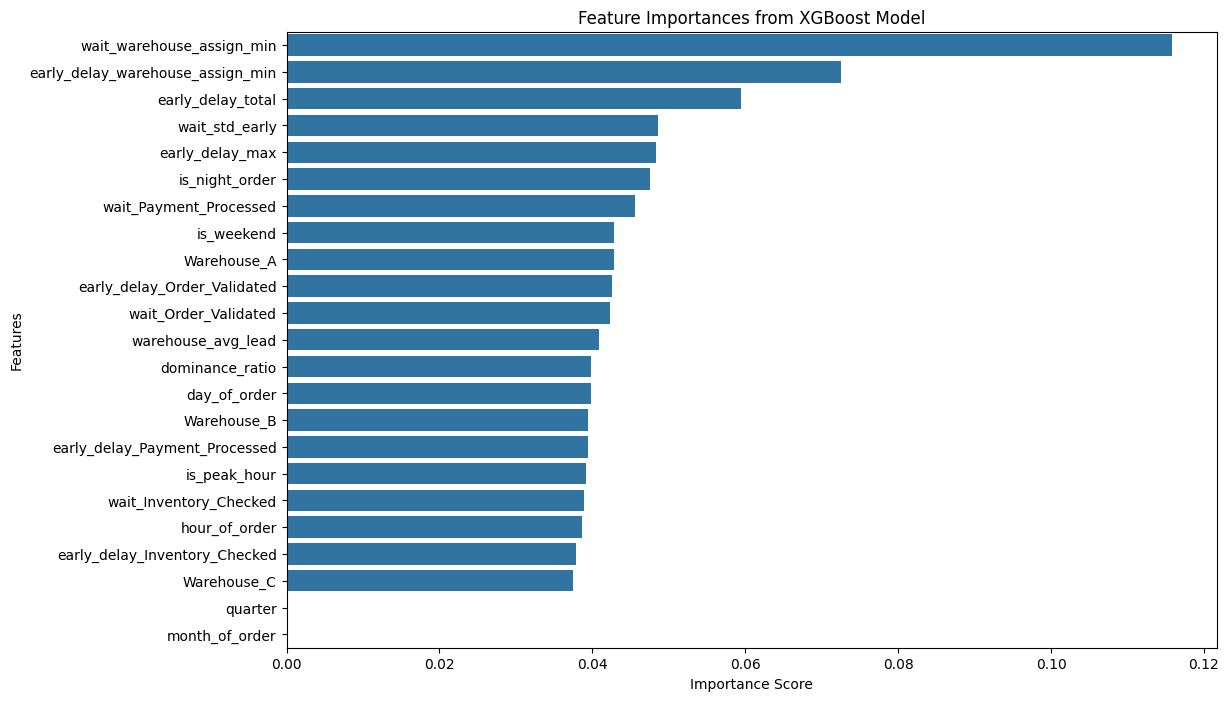

Top 10 Feature Importances:
wait_warehouse_assign_min           0.115849
early_delay_warehouse_assign_min    0.072517
early_delay_total                   0.059495
wait_std_early                      0.048538
early_delay_max                     0.048372
is_night_order                      0.047595
wait_Payment_Processed              0.045521
is_weekend                          0.042856
Warehouse_A                         0.042839
early_delay_Order_Validated         0.042511
dtype: float32


In [49]:
feature_importances = model.feature_importances_
feature_names = X.columns

# Create a pandas Series for better handling and sorting
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importance = importance_series.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance.values, y=sorted_importance.index)
plt.title('Feature Importances from XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print('Top 10 Feature Importances:')
print(sorted_importance.head(10))